In [24]:
# Colab setup — skip if running locally
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install -q mne einops torch torchvision scikit-learn
    from google.colab import drive
    drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
%cd drive/MyDrive/Neurotech\ 25-26/ml_model

[Errno 2] No such file or directory: 'drive/MyDrive/Neurotech 25-26/ml_model'
/content/drive/MyDrive/Neurotech 25-26/ml_model


In [26]:
%ls

loso_dl_models/  models.py               __pycache__/
loso_models/     preprocess_pipeline.py  train_loso.ipynb


In [27]:
import os
import sys
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, confusion_matrix, classification_report

# Path setup — works both locally and on Colab (after mounting Drive)
if 'google.colab' in sys.modules:
    REPO_ROOT = '/content/drive/MyDrive/weimo'
else:
    REPO_ROOT = os.path.join(os.path.dirname(os.path.abspath('.')), '')

sys.path.insert(0, REPO_ROOT)
from preprocess_pipeline import MNEPipeline, notch, bandpass, rereference, add_idle_class, epoch, epoch_filter, extract_tensor
from models import DeepConvNet, ShallowConvNet, EEGNet, ATCNet, Conformer, CTNet, MBMANet, LMDANet, EEGITNet

In [28]:
# =============================================================================
# Configuration
# =============================================================================

N_CHANNELS   = 8
N_CLASSES    = 2
SFREQ        = 300
TRIAL_DUR    = 3.0
N_TIMEPOINTS = int(SFREQ * TRIAL_DUR) + 1  # 901 — MNE tmax is inclusive

LABEL_MAP = {'idle': 0, 'move': 1, 'jaw_clench': 0}
MAP_LABEL = {v: k for k, v in LABEL_MAP.items()}
BANDPASS  = [(13, 30)]   # best config from gridsearch

EPOCHS     = 500
BATCH_SIZE = 32
LR         = 1e-4        # best lr from gridsearch
PATIENCE   = 20
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── File paths ────────────────────────────────────────────────────────────────
# Local paths (relative to ml_model/). Update the Colab block if running on Drive.
if 'google.colab' in sys.modules:
    DATA_DIR = '/content/drive/MyDrive/Neurotech 25-26/data/annotated_eeg'
else:
    DATA_DIR = os.path.join(REPO_ROOT, 'data_collection', 'annotated_eeg')

FILES = [
    os.path.join(DATA_DIR, 'chengyi_4_8_0.fif'),
    os.path.join(DATA_DIR, 'chengyi_4_8_1.fif'),
    os.path.join(DATA_DIR, 'chengyi_4_9_0.fif'),
    os.path.join(DATA_DIR, 'chengyi_4_9_1.fif'),
    os.path.join(DATA_DIR, 'chengyi_4_9_2.fif'),
    # os.path.join(DATA_DIR, 'chengyi_4_21_1.fif')
]

TARGET   = '+'.join(sorted(k for k, v in LABEL_MAP.items() if v == 1)) if N_CLASSES == 2 else 'multiclass'
SAVE_DIR = f'./loso_dl_models/{TARGET}'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Preprocessing modes to compare ──────────────────────────────────────────
# Each entry runs as a separate LOSO sweep. Remove one to skip it.
PREPROCESS_MODES = {
    # 'whole_file': False,  # filter continuous recording → epoch
    'per_epoch' : True,   # epoch first → filter each trial independently
}

print(f'Device      : {DEVICE}')
print(f'N_TIMEPOINTS: {N_TIMEPOINTS}')
print(f'Files       : {len(FILES)}')

Device      : cuda
N_TIMEPOINTS: 901
Files       : 5


In [29]:
# =============================================================================
# Model registry
# =============================================================================

MODEL_REGISTRY = {
    'DeepConvNet'  : lambda: DeepConvNet(N_CHANNELS, N_CLASSES),
    # 'ShallowConvNet': lambda: ShallowConvNet(N_CHANNELS, N_CLASSES),
    # 'EEGNet'       : lambda: EEGNet(N_CHANNELS, N_CLASSES, N_TIMEPOINTS, SFREQ),
    # 'ATCNet'       : lambda: ATCNet(N_CHANNELS, N_CLASSES, SFREQ),
    # 'Conformer'    : lambda: Conformer(N_CHANNELS, N_CLASSES, N_TIMEPOINTS),
    # 'CTNet'        : lambda: CTNet(N_CHANNELS, N_CLASSES, N_TIMEPOINTS, SFREQ),
    # 'MBMANet'      : lambda: MBMANet(N_CHANNELS, N_CLASSES, N_TIMEPOINTS, SFREQ),
    # 'LMDANet'      : lambda: LMDANet(N_CHANNELS, N_CLASSES, N_TIMEPOINTS),
    # 'EEGITNet'     : lambda: EEGITNet(N_CHANNELS, N_CLASSES, N_TIMEPOINTS),
}

In [30]:
# =============================================================================
# Data loading
# =============================================================================

def load_session(fif_path, per_epoch=False):
    """Preprocess one .fif file and return (X, y) with integer labels.

    X shape: (n_trials, 1, N_CHANNELS, N_TIMEPOINTS)  float32
    y shape: (n_trials,)  int64

    per_epoch=False: filter/rereference on the continuous recording, then epoch.
    per_epoch=True : epoch with minimal processing first, then filter each trial.
    """
    extractor = extract_tensor(scale=True, per_epoch_scale=True)

    pipeline = MNEPipeline(fif_path)
    if not per_epoch:
        pipeline.add(notch(60))
        pipeline.add(bandpass(BANDPASS))
        pipeline.add(rereference())
    pipeline.add(add_idle_class(window_dur=TRIAL_DUR, idle_start_min=1.0))
    pipeline.add(epoch(tmin=0, tmax=TRIAL_DUR))
    if per_epoch:
        pipeline.add(epoch_filter(bands=BANDPASS, notch_freq=60, ref='average'))
    raw = pipeline.run()

    X, y_raw = extractor(raw)

    # remap MNE's auto-assigned event IDs to consistent 0/1/2
    auto_ids = raw._event_id
    remap = {v: LABEL_MAP[k] for k, v in auto_ids.items() if k in LABEL_MAP}
    y = np.array([remap[yi] for yi in y_raw], dtype=np.int64)

    # trim/pad to exact N_TIMEPOINTS in case of rounding differences
    T = X.shape[-1]
    if T > N_TIMEPOINTS:
        X = X[..., :N_TIMEPOINTS]
    elif T < N_TIMEPOINTS:
        pad = np.zeros((*X.shape[:-1], N_TIMEPOINTS - T), dtype=np.float32)
        X = np.concatenate([X, pad], axis=-1)

    print(f'  {os.path.basename(fif_path)}: X={X.shape}  classes={dict(zip(*np.unique(y, return_counts=True)))}')
    return X, y


def balance_classes(X, y):
    """Undersample majority classes to match the smallest class."""
    unique, counts = np.unique(y, return_counts=True)
    min_count = counts.min()
    idx = np.concatenate([
        np.random.choice(np.where(y == c)[0], size=min_count, replace=False)
        for c in unique
    ])
    np.random.shuffle(idx)
    return X[idx], y[idx]


In [31]:
# =============================================================================
# Preload all sessions (one set per preprocessing mode)
# =============================================================================

print('Loading sessions...')
all_sessions = {
    mode: [load_session(f, per_epoch=flag) for f in FILES]
    for mode, flag in PREPROCESS_MODES.items()
}
print(f'\nDone. {len(FILES)} sessions × {len(PREPROCESS_MODES)} preprocessing modes loaded.')


Loading sessions...
Opening raw data file /content/drive/MyDrive/Neurotech 25-26/data/annotated_eeg/chengyi_4_8_0.fif...
Isotrak not found
    Range : 0 ... 287999 =      0.000 ...   959.997 secs
Ready.
Reading 0 ... 287999  =      0.000 ...   959.997 secs...
Applying: <function add_idle_class.<locals>.apply at 0x789a503311c0>
[idle] Added 131 idle windows  |  label: 'idle'
Applying: <function epoch.<locals>.apply at 0x789a50331b20>
Used Annotations descriptions: [np.str_('idle'), np.str_('jaw_clench'), np.str_('move')]
Not setting metadata
205 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 205 events and 901 original time points ...
0 bad epochs dropped
Epoched: 205 trials  |  classes: [np.str_('idle'), np.str_('jaw_clench'), np.str_('move')]
Applying: <function epoch_filter.<locals>.apply at 0x789a50331940>


/content/drive/MyDrive/Neurotech 25-26/ml_model/preprocess_pipeline.py:340: RuntimeWarning: This filename (/content/drive/MyDrive/Neurotech 25-26/data/annotated_eeg/chengyi_4_8_0.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(self.fif_file, preload=True)
/content/drive/MyDrive/Neurotech 25-26/ml_model/preprocess_pipeline.py:196: RuntimeWarning: filter_length (1981) is longer than the signal (901), distortion is likely. Reduce filter length or filter a longer signal.
  data = mne.filter.notch_filter(data, Fs=raw._epochs.info['sfreq'], freqs=notch_freq, verbose=False)


[Tensor] shape: (205, 1, 8, 901)  scale=per-epoch
  chengyi_4_8_0.fif: X=(205, 1, 8, 901)  classes={np.int64(0): np.int64(167), np.int64(1): np.int64(38)}
Opening raw data file /content/drive/MyDrive/Neurotech 25-26/data/annotated_eeg/chengyi_4_8_1.fif...
Isotrak not found
    Range : 0 ... 271799 =      0.000 ...   905.997 secs
Ready.
Reading 0 ... 271799  =      0.000 ...   905.997 secs...
Applying: <function add_idle_class.<locals>.apply at 0x789a517cdb20>
[idle] Added 123 idle windows  |  label: 'idle'
Applying: <function epoch.<locals>.apply at 0x789a517efec0>
Used Annotations descriptions: [np.str_('idle'), np.str_('jaw_clench'), np.str_('move')]
Not setting metadata
197 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 197 events and 901 original time points ...
0 bad epochs dropped
Epoched: 197 trials  |  classes: [np.str_('idle'), np.str_('jaw_clench'), np.str_('move')]
Applying: <function epoch_filter.<locals>.

/content/drive/MyDrive/Neurotech 25-26/ml_model/preprocess_pipeline.py:340: RuntimeWarning: This filename (/content/drive/MyDrive/Neurotech 25-26/data/annotated_eeg/chengyi_4_8_1.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(self.fif_file, preload=True)
/content/drive/MyDrive/Neurotech 25-26/ml_model/preprocess_pipeline.py:196: RuntimeWarning: filter_length (1981) is longer than the signal (901), distortion is likely. Reduce filter length or filter a longer signal.
  data = mne.filter.notch_filter(data, Fs=raw._epochs.info['sfreq'], freqs=notch_freq, verbose=False)


[Tensor] shape: (197, 1, 8, 901)  scale=per-epoch
  chengyi_4_8_1.fif: X=(197, 1, 8, 901)  classes={np.int64(0): np.int64(159), np.int64(1): np.int64(38)}
Opening raw data file /content/drive/MyDrive/Neurotech 25-26/data/annotated_eeg/chengyi_4_9_0.fif...
Isotrak not found
    Range : 0 ... 263999 =      0.000 ...   879.997 secs
Ready.
Reading 0 ... 263999  =      0.000 ...   879.997 secs...
Applying: <function add_idle_class.<locals>.apply at 0x789a517efec0>
[idle] Added 112 idle windows  |  label: 'idle'
Applying: <function epoch.<locals>.apply at 0x789a502005e0>
Used Annotations descriptions: [np.str_('idle'), np.str_('jaw_clench'), np.str_('move')]
Not setting metadata
186 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 186 events and 901 original time points ...
0 bad epochs dropped
Epoched: 186 trials  |  classes: [np.str_('idle'), np.str_('jaw_clench'), np.str_('move')]
Applying: <function epoch_filter.<locals>.

...

[Tensor] shape: (186, 1, 8, 901)  scale=per-epoch
  chengyi_4_9_0.fif: X=(186, 1, 8, 901)  classes={np.int64(0): np.int64(148), np.int64(1): np.int64(38)}
Opening raw data file /content/drive/MyDrive/Neurotech 25-26/data/annotated_eeg/chengyi_4_9_1.fif...
Isotrak not found
    Range : 0 ... 272999 =      0.000 ...   909.997 secs
Ready.
Reading 0 ... 272999  =      0.000 ...   909.997 secs...
Applying: <function add_idle_class.<locals>.apply at 0x789a502005e0>
[idle] Added 119 idle windows  |  label: 'idle'
Applying: <function epoch.<locals>.apply at 0x789bd0414b80>
Used Annotations descriptions: [np.str_('idle'), np.str_('jaw_clench'), np.str_('move')]
Not setting metadata
193 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 193 events and 901 original time points ...
0 bad epochs dropped
Epoched: 193 trials  |  classes: [np.str_('idle'), np.str_('jaw_clench'), np.str_('move')]
Applying: <function epoch_filter.<locals>.

/content/drive/MyDrive/Neurotech 25-26/ml_model/preprocess_pipeline.py:340: RuntimeWarning: This filename (/content/drive/MyDrive/Neurotech 25-26/data/annotated_eeg/chengyi_4_9_1.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(self.fif_file, preload=True)
/content/drive/MyDrive/Neurotech 25-26/ml_model/preprocess_pipeline.py:196: RuntimeWarning: filter_length (1981) is longer than the signal (901), distortion is likely. Reduce filter length or filter a longer signal.
  data = mne.filter.notch_filter(data, Fs=raw._epochs.info['sfreq'], freqs=notch_freq, verbose=False)


[Tensor] shape: (193, 1, 8, 901)  scale=per-epoch
  chengyi_4_9_1.fif: X=(193, 1, 8, 901)  classes={np.int64(0): np.int64(155), np.int64(1): np.int64(38)}
Opening raw data file /content/drive/MyDrive/Neurotech 25-26/data/annotated_eeg/chengyi_4_9_2.fif...
Isotrak not found
    Range : 0 ... 266999 =      0.000 ...   889.997 secs
Ready.
Reading 0 ... 266999  =      0.000 ...   889.997 secs...
Applying: <function add_idle_class.<locals>.apply at 0x789a502005e0>
[idle] Added 115 idle windows  |  label: 'idle'
Applying: <function epoch.<locals>.apply at 0x789bd0414b80>
Used Annotations descriptions: [np.str_('idle'), np.str_('jaw_clench'), np.str_('move')]
Not setting metadata
189 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 189 events and 901 original time points ...
0 bad epochs dropped
Epoched: 189 trials  |  classes: [np.str_('idle'), np.str_('jaw_clench'), np.str_('move')]
Applying: <function epoch_filter.<locals>.

/content/drive/MyDrive/Neurotech 25-26/ml_model/preprocess_pipeline.py:340: RuntimeWarning: This filename (/content/drive/MyDrive/Neurotech 25-26/data/annotated_eeg/chengyi_4_9_2.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(self.fif_file, preload=True)
/content/drive/MyDrive/Neurotech 25-26/ml_model/preprocess_pipeline.py:196: RuntimeWarning: filter_length (1981) is longer than the signal (901), distortion is likely. Reduce filter length or filter a longer signal.
  data = mne.filter.notch_filter(data, Fs=raw._epochs.info['sfreq'], freqs=notch_freq, verbose=False)


[Tensor] shape: (189, 1, 8, 901)  scale=per-epoch
  chengyi_4_9_2.fif: X=(189, 1, 8, 901)  classes={np.int64(0): np.int64(151), np.int64(1): np.int64(38)}

Done. 5 sessions × 1 preprocessing modes loaded.


In [32]:
# =============================================================================
# Training utilities
# =============================================================================

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(yb)
        correct    += (out.argmax(1) == yb).sum().item()
        n          += len(yb)
    return total_loss / n, correct / n


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        loss = criterion(out, yb)
        total_loss += loss.item() * len(yb)
        correct    += (out.argmax(1) == yb).sum().item()
        n          += len(yb)
    return total_loss / n, correct / n


@torch.no_grad()
def compute_metrics(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    for xb, yb in loader:
        preds = model(xb.to(device)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())
    acc   = accuracy_score(all_labels, all_preds)
    f1    = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    kappa = cohen_kappa_score(all_labels, all_preds)
    cm    = confusion_matrix(all_labels, all_preds)
    return {'accuracy': acc, 'f1_macro': f1, 'kappa': kappa, 'confusion_matrix': cm,
            'preds': all_preds, 'labels': all_labels}

In [33]:
# =============================================================================
# LOSO training loop
# =============================================================================

all_results = []

# best model per (architecture, preprocessing mode)
best_per_model = {
    name: {mode: {'accuracy': -1} for mode in PREPROCESS_MODES}
    for name in MODEL_REGISTRY
}

for preproc_name, per_epoch_flag in PREPROCESS_MODES.items():
    sessions = all_sessions[preproc_name]
    print(f'\n{"#"*60}')
    print(f'PREPROCESSING MODE: {preproc_name}')
    print(f'{"#"*60}')

    for fold_idx in range(len(FILES)):
        val_session = os.path.basename(FILES[fold_idx])
        print(f'\n{"="*60}')
        print(f'FOLD {fold_idx+1}/{len(FILES)}  |  Val session: {val_session}')
        print(f'{"="*60}')

        val_X, val_y = sessions[fold_idx]

        train_X = np.concatenate([sessions[j][0] for j in range(len(FILES)) if j != fold_idx])
        train_y = np.concatenate([sessions[j][1] for j in range(len(FILES)) if j != fold_idx])
        train_X, train_y = balance_classes(train_X, train_y)

        print(f'  Train: {train_X.shape}  Val: {val_X.shape}')
        unique, counts = np.unique(train_y, return_counts=True)
        print(f'  Train class dist: { {MAP_LABEL[c]: int(n) for c, n in zip(unique, counts)} }')
        unique, counts = np.unique(val_y, return_counts=True)
        print(f'  Val class dist  : { {MAP_LABEL[c]: int(n) for c, n in zip(unique, counts)} }')

        train_ds = TensorDataset(torch.tensor(train_X), torch.tensor(train_y))
        val_ds   = TensorDataset(torch.tensor(val_X),   torch.tensor(val_y))
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
        val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)

        criterion = nn.CrossEntropyLoss()

        for model_name, model_fn in MODEL_REGISTRY.items():
            print(f'\n  [{model_name}]')
            try:
                model     = model_fn().to(DEVICE)
                optimizer = torch.optim.Adam(model.parameters(), lr=LR)
                scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

                best_val_loss  = float('inf')
                best_state     = None
                patience_count = 0

                for ep in range(1, EPOCHS + 1):
                    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
                    va_loss, va_acc = eval_epoch(model, val_loader, criterion, DEVICE)
                    scheduler.step()

                    if ep % 50 == 0:
                        print(f'    ep {ep:3d} | tr {tr_loss:.4f}/{tr_acc:.3f} | va {va_loss:.4f}/{va_acc:.3f}')

                    if va_loss < best_val_loss - 1e-4:
                        best_val_loss  = va_loss
                        best_state     = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                        patience_count = 0
                    else:
                        patience_count += 1
                        if patience_count >= PATIENCE:
                            print(f'    Early stop at epoch {ep}')
                            break

                model.load_state_dict(best_state)
                metrics = compute_metrics(model, val_loader, DEVICE)

                print(f'    acc={metrics["accuracy"]:.4f}  f1={metrics["f1_macro"]:.4f}  kappa={metrics["kappa"]:.4f}')

                result = {
                    'fold'        : fold_idx,
                    'val_session' : val_session,
                    'preproc'     : preproc_name,
                    'model_name'  : model_name,
                    'accuracy'    : metrics['accuracy'],
                    'f1_macro'    : metrics['f1_macro'],
                    'kappa'       : metrics['kappa'],
                    'confusion_matrix': metrics['confusion_matrix'].tolist(),
                    'model'       : model,
                }
                all_results.append(result)

                if metrics['accuracy'] > best_per_model[model_name][preproc_name]['accuracy']:
                    best_per_model[model_name][preproc_name] = result
                    save_path = os.path.join(SAVE_DIR, f'{model_name}_{preproc_name}.pt')
                    torch.save(best_state, save_path)
                    config = {
                        'model_name'  : model_name,
                        'preproc'     : preproc_name,
                        'val_session' : val_session,
                        'accuracy'    : metrics['accuracy'],
                        'f1_macro'    : metrics['f1_macro'],
                        'kappa'       : metrics['kappa'],
                        'N_CHANNELS'  : N_CHANNELS,
                        'N_CLASSES'   : N_CLASSES,
                        'N_TIMEPOINTS': N_TIMEPOINTS,
                        'SFREQ'       : SFREQ,
                        'TRIAL_DUR'   : TRIAL_DUR,
                        'BANDPASS'    : BANDPASS,
                    }
                    with open(save_path.replace('.pt', '_config.json'), 'w') as f:
                        json.dump(config, f, indent=2)
                    print(f'    Saved best {model_name}/{preproc_name} (acc={metrics["accuracy"]:.4f})')

            except Exception as e:
                print(f'    ERROR: {e}')
                all_results.append({
                    'fold': fold_idx, 'val_session': val_session,
                    'preproc': preproc_name, 'model_name': model_name,
                    'accuracy': None, 'f1_macro': None, 'kappa': None,
                    'confusion_matrix': None, 'model': None,
                })

print('\nLOSO training complete.')



############################################################
PREPROCESSING MODE: per_epoch
############################################################

FOLD 1/5  |  Val session: chengyi_4_8_0.fif
  Train: (304, 1, 8, 901)  Val: (205, 1, 8, 901)
  Train class dist: {'jaw_clench': 152, 'move': 152}
  Val class dist  : {'jaw_clench': 167, 'move': 38}

  [DeepConvNet]
    ep  50 | tr 0.3144/1.000 | va 0.5174/0.785
    Early stop at epoch 59
    acc=0.8439  f1=0.7515  kappa=0.5033
    Saved best DeepConvNet/per_epoch (acc=0.8439)

FOLD 2/5  |  Val session: chengyi_4_8_1.fif
  Train: (304, 1, 8, 901)  Val: (197, 1, 8, 901)
  Train class dist: {'jaw_clench': 152, 'move': 152}
  Val class dist  : {'jaw_clench': 159, 'move': 38}

  [DeepConvNet]
    Early stop at epoch 41
    acc=0.8173  f1=0.7123  kappa=0.4246

FOLD 3/5  |  Val session: chengyi_4_9_0.fif
  Train: (304, 1, 8, 901)  Val: (186, 1, 8, 901)
  Train class dist: {'jaw_clench': 152, 'move': 152}
  Val class dist  : {'jaw_clench': 14

In [34]:
# =============================================================================
# Results table
# =============================================================================

df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('model', 'confusion_matrix')}
    for r in all_results
])
df = df.dropna(subset=['accuracy'])

summary = (
    df.groupby(['preproc', 'model_name'])[['accuracy', 'f1_macro', 'kappa']]
    .agg(['mean', 'std'])
    .round(4)
    .sort_values(('accuracy', 'mean'), ascending=False)
)
print('LOSO summary (mean ± std across folds):')
print(summary.to_string())


LOSO summary (mean ± std across folds):
                      accuracy         f1_macro           kappa        
                          mean     std     mean     std    mean     std
preproc   model_name                                                   
per_epoch DeepConvNet   0.8289  0.0235   0.7474  0.0298  0.4969  0.0587


In [35]:
# =============================================================================
# Per-fold breakdown
# =============================================================================

pivot = df.pivot_table(
    index=['preproc', 'model_name'], columns='val_session', values='accuracy'
).round(4)
pivot['mean'] = pivot.mean(axis=1)
pivot = pivot.sort_values('mean', ascending=False)
print('Accuracy per held-out session:')
print(pivot.to_string())


Accuracy per held-out session:
val_session            chengyi_4_8_0.fif  chengyi_4_8_1.fif  chengyi_4_9_0.fif  chengyi_4_9_1.fif  chengyi_4_9_2.fif     mean
preproc   model_name                                                                                                         
per_epoch DeepConvNet             0.8439             0.8173             0.8441             0.7927             0.8466  0.82892


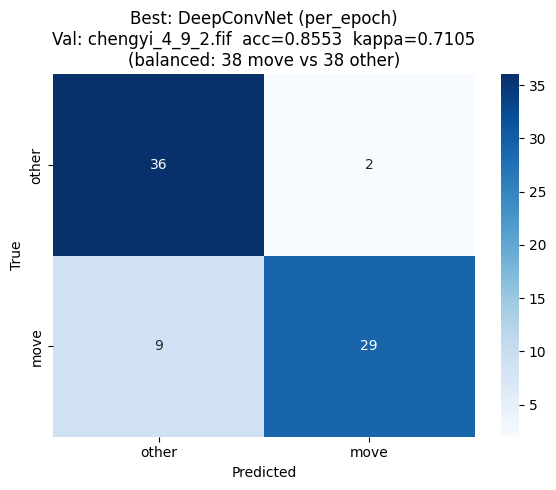

Best: DeepConvNet (per_epoch)  val=chengyi_4_9_2.fif  acc=0.8553


In [37]:
# =============================================================================
# Confusion matrix — best model + preprocessing mode, best fold
# Other trials subsampled to match move trial count for a fair display
# =============================================================================

best_result = max(
    [r for r in all_results if r['accuracy'] is not None],
    key=lambda r: r['accuracy']
)

# Balance val set: subsample other (class != move) down to match move count
val_X, val_y = all_sessions[best_result['preproc']][best_result['fold']]
move_label = LABEL_MAP['move']
move_idx   = np.where(val_y == move_label)[0]
other_idx  = np.where(val_y != move_label)[0]
other_idx  = np.random.choice(other_idx, size=len(move_idx), replace=False)
bal_idx    = np.concatenate([move_idx, other_idx])
bal_X, bal_y = val_X[bal_idx], val_y[bal_idx]

bal_loader  = DataLoader(TensorDataset(torch.tensor(bal_X), torch.tensor(bal_y)), batch_size=BATCH_SIZE)
metrics_bal = compute_metrics(best_result['model'], bal_loader, DEVICE)
cm          = metrics_bal['confusion_matrix']

def _class_name(i):
    keys = [k for k, v in LABEL_MAP.items() if v == i]
    return keys[0] if len(keys) == 1 else "other"
class_names = [_class_name(i) for i in sorted(set(LABEL_MAP.values()))]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(
    f'Best: {best_result["model_name"]} ({best_result["preproc"]})\n'
    f'Val: {best_result["val_session"]}  '
    f'acc={metrics_bal["accuracy"]:.4f}  kappa={metrics_bal["kappa"]:.4f}\n'
    f'(balanced: {len(move_idx)} move vs {len(move_idx)} other)'
)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'best_confusion_matrix.png'), dpi=120)
plt.show()
print(f'Best: {best_result["model_name"]} ({best_result["preproc"]})  val={best_result["val_session"]}  acc={metrics_bal["accuracy"]:.4f}')
